/tmp/ipykernel_136627/2813687187.py:41: UserWarning: 
The markers list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(


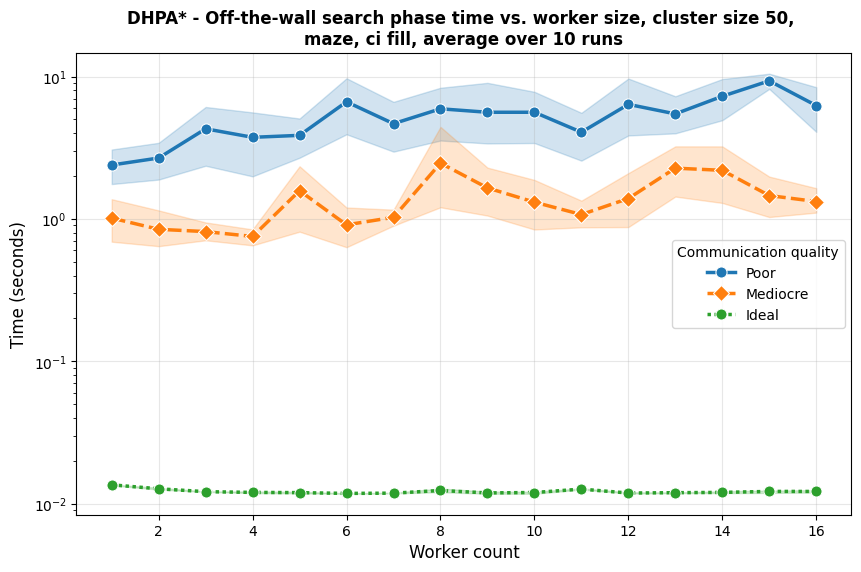

/tmp/ipykernel_136627/2813687187.py:68: UserWarning: 
The markers list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(


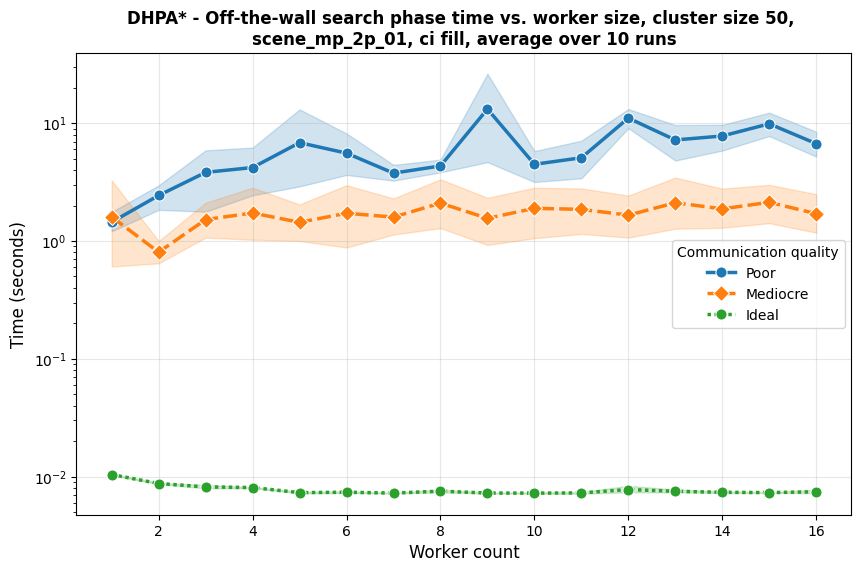

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Mapping of file names to their corresponding attributes
files = {
    "dhpa_pl_poor_maze.json": {"Communication quality": "Poor", "Map": "maze"},
    "dhpa_pl_poor_mp2.json": {"Communication quality": "Poor", "Map": "mp2"},
    "dhpa_pl_med_maze.json": {"Communication quality": "Mediocre", "Map": "maze"},
    "dhpa_pl_med_mp2.json": {"Communication quality": "Mediocre", "Map": "mp2"},
    "dhpa_pl_ideal_mp2.json": {"Communication quality": "Ideal", "Map": "mp2"},
    "dhpa_pl_ideal_maze.json": {"Communication quality": "Ideal", "Map": "maze"}
}

all_records = []

# Parse and combine JSON data
for f, info in files.items():
    with open(f, 'r') as file:
        content = json.load(file)
        for row in content['data']:
            record = {
                "cluster_size": row['cluster_size'],
                "workers_size": row['workers_size'],
                "algorithm": row['algorithm'],
                "run": row['run'],
                "Value": row['timings']['found_overall_path'] + row['timings']['found_graph_path'] + row['timings']['finish_abstract_graph'],
                "Communication quality": info['Communication quality'],
                "Map": info['Map']
            }
            all_records.append(record)

df = pd.DataFrame(all_records)
# df = df[df['Value'] != 0]

# 1. Generate the line plot for the 'maze' map
df_maze = df[df['Map'] == 'maze']
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(
    data=df_maze,
    x="workers_size",
    y="Value",
    hue="Communication quality",
    style="Communication quality",
    markers=['o', 'D'],
    markersize=8,
    palette="tab10",
    linewidth=2.5,
    errorbar='ci',  # Computes SD across runs
    ax=ax
)

ax.set_yscale('log')
ax.set_title('DHPA* - Off-the-wall search phase time vs. worker size, cluster size 50, \nmaze, ci fill, average over 10 runs', fontsize=12, fontweight='bold')
ax.set_xlabel('Worker count', fontsize=12)
ax.set_ylabel('Time (seconds)', fontsize=12)
ax.grid(True, alpha=0.3)

plt.show()
plt.close()

# 2. Generate the line plot for the 'mp2' map
df_mp2 = df[df['Map'] == 'mp2']
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(
    data=df_mp2,
    x="workers_size",
    y="Value",
    hue="Communication quality",
    style="Communication quality",
    markers=['o', 'D'],
    markersize=8,
    palette="tab10",
    linewidth=2.5,
    errorbar='ci',  # Computes SD across runs
    ax=ax
)

ax.set_yscale('log')
ax.set_title('DHPA* - Off-the-wall search phase time vs. worker size, cluster size 50, \nscene_mp_2p_01, ci fill, average over 10 runs', fontsize=12, fontweight='bold')
ax.set_xlabel('Worker count', fontsize=12)
ax.set_ylabel('Time (seconds)', fontsize=12)
ax.grid(True, alpha=0.3)

plt.show()
plt.close()